[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/No-Country-simulation/G9-BR-Team-19/blob/main/Data%20Science/TechMind_Oficial.ipynb)

# <font color="#0a8f08">**G9-BR-Team-19**</font>

# <font color='red' style='font-size: 30px;'>1.2 Imports</font>
<hr style='border: 2px solid red;'>

In [ ]:
import re
import string
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_colwidth', 120)

# <font color='red' style='font-size: 30px;'>1.3 Geração do DataSet</font>
<hr style='border: 2px solid red;'>

In [ ]:
SUBTOPICS = {
    "Backend": [
        "APIs REST", "Spring Boot", "Node.js e Express", "autenticação JWT",
        "arquitetura de microsserviços", "bancos de dados relacionais",
        "ORM e Hibernate", "mensageria com RabbitMQ", "GraphQL",
        "cache com Redis", "testes unitários em Java", "Clean Architecture",
        "versionamento de APIs", "tratamento de exceções em APIs"
    ],
    "Frontend": [
        "React.js", "componentes reutilizáveis", "gerenciamento de estado com Redux",
        "Vue.js", "CSS Grid e Flexbox", "acessibilidade web",
        "TypeScript no front-end", "performance de renderização",
        "Webpack e bundling", "design responsivo", "hooks do React", "Next.js",
        "consumo de APIs no front-end", "testes de componentes com Jest"
    ],
    "Data Science": [
        "análise exploratória de dados", "machine learning supervisionado",
        "processamento de linguagem natural", "pandas e manipulação de dados",
        "modelos de classificação", "engenharia de features",
        "visualização de dados", "redes neurais", "regressão logística",
        "clustering e agrupamento", "métricas de avaliação de modelos",
        "scikit-learn", "séries temporais", "validação cruzada"
    ],
    "DevOps": [
        "integração contínua", "pipelines de CI/CD", "containers com Docker",
        "orquestração com Kubernetes", "infraestrutura como código",
        "monitoramento e observabilidade", "Terraform", "automação de deploy",
        "Jenkins", "GitOps", "escalabilidade de infraestrutura",
        "logs centralizados", "gestão de segredos", "blue-green deployment"
    ],
    "Mobile": [
        "desenvolvimento com Flutter", "aplicativos Android nativos",
        "Swift e iOS", "React Native", "UI mobile responsiva",
        "notificações push", "armazenamento local em apps",
        "ciclo de vida de atividades Android", "publicação na Play Store",
        "consumo de APIs REST em apps móveis", "performance de aplicativos móveis",
        "Kotlin", "testes de interface em apps", "modo offline em aplicativos"
    ],
    "Cloud": [
        "computação em nuvem", "armazenamento em nuvem (Object Storage)",
        "OCI Compute", "serverless e Functions", "escalabilidade automática",
        "redes virtuais na nuvem", "segurança em ambientes cloud",
        "migração para a nuvem", "provedores AWS e Azure",
        "custos e otimização em cloud", "bancos de dados gerenciados na nuvem",
        "alta disponibilidade", "balanceamento de carga na nuvem",
        "backup e recuperação de desastres"
    ],
}

TITLE_TEMPLATES = [
    "Introdução a {t1}",
    "Como funciona {t1}",
    "Boas práticas em {t1}",
    "Guia completo sobre {t1}",
    "Entendendo {t1} na prática",
    "{t1}: conceitos essenciais",
    "Um panorama sobre {t1}",
    "Primeiros passos com {t1}",
]

TEXT_TEMPLATES = [
    "Este conteúdo apresenta os principais conceitos sobre {t1}. São abordados temas "
    "como {t2} e {t3}, além de exemplos práticos de aplicação no dia a dia de "
    "desenvolvimento. O objetivo é fornecer uma base sólida para quem deseja "
    "aprofundar conhecimentos em {t1}.",

    "Neste material, discutimos {t1} com foco em aplicações reais. Também são "
    "explorados aspectos relacionados a {t2}, com dicas de boas práticas e "
    "armadilhas comuns. Ao final, o leitor terá uma visão prática sobre {t3}.",

    "Um estudo detalhado sobre {t1}, cobrindo desde os fundamentos até tópicos mais "
    "avançados como {t2}. O texto também relaciona {t1} com {t3}, mostrando como "
    "esses conceitos se conectam em projetos do mundo real.",

    "Esta documentação técnica explica {t1} passo a passo, com exemplos de código "
    "e cenários de uso. Também é discutida a relação entre {t2} e {t3}, "
    "reforçando quando cada abordagem deve ser utilizada.",

    "Notas de estudo sobre {t1}: principais definições, vantagens e desvantagens. "
    "O conteúdo também compara {t1} com {t2} e apresenta um exemplo prático "
    "envolvendo {t3} para fixar o aprendizado.",

    "Tutorial prático que ensina {t1} do zero. Ao longo do texto, também são "
    "apresentados conceitos de {t2}, e ao final é proposto um exercício "
    "envolvendo {t3} para consolidar o conteúdo.",
]

N_PER_CATEGORY = 150  # Aumentei para 150, antes era 60

RESUMO_TEMPLATES = [
    "Resumo: visão geral sobre {t1}, com destaque para {t2} e {t3}.",
    "Resumo: principais conceitos de {t1}, relacionando-os com {t2} e {t3}.",
    "Resumo: guia rápido sobre {t1}, abordando também {t2} e {t3}.",
    "Resumo: panorama prático de {t1}, com menções a {t2} e {t3}.",
]

def generate_dataset(ruido_pct=0.25, ruido_titulo_pct=0.10):
    rows = []
    categorias = list(SUBTOPICS.keys())
    for categoria, subtopics in SUBTOPICS.items():
        for _ in range(N_PER_CATEGORY):
            t1, t2, t3 = random.sample(subtopics, 3)

            # Contamina t3 (mais frequente)
            if random.random() < ruido_pct:
                outra_cat = random.choice([c for c in categorias if c != categoria])
                t3 = random.choice(SUBTOPICS[outra_cat])

            # Contamina t2 também, com chance um pouco menor
            if random.random() < ruido_pct * 0.7:
                outra_cat = random.choice([c for c in categorias if c != categoria])
                t2 = random.choice(SUBTOPICS[outra_cat])

            # Contamina até o t1 (usado no TÍTULO), mas com chance bem menor agora
            if random.random() < ruido_titulo_pct:
                outra_cat = random.choice([c for c in categorias if c != categoria])
                t1 = random.choice(SUBTOPICS[outra_cat])

            title = random.choice(TITLE_TEMPLATES).format(t1=t1)
            text = random.choice(TEXT_TEMPLATES).format(t1=t1, t2=t2, t3=t3)
            resumo = random.choice(RESUMO_TEMPLATES).format(t1=t1, t2=t2, t3=t3)
            rows.append({
                "titulo": title,
                "texto": text,
                "categoria": categoria,
                "tag1": t1,
                "tag2": t2,
                "tag3": t3,
                "resumo": resumo,
            })
    df = pd.DataFrame(rows)
    df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return df

df = generate_dataset(ruido_pct=0.25, ruido_titulo_pct=0.10)
df.to_csv("techmind_dataset.csv", index=False)
print(f"Base gerada com {len(df)} registros ({df['categoria'].nunique()} categorias).")
df.head(3)

Base gerada com 900 registros (6 categorias).


,titulo,texto,categoria,tag1,tag2,tag3,resumo
0,Primeiros passos com autenticação JWT,"Um estudo detalhado sobre autenticação JWT, cobrindo desde os fundamentos até tópicos mais avançados como versioname...",Backend,autenticação JWT,versionamento de APIs,mensageria com RabbitMQ,"Resumo: principais conceitos de autenticação JWT, relacionando-os com versionamento de APIs e mensageria com RabbitMQ."
1,alta disponibilidade: conceitos essenciais,"Esta documentação técnica explica alta disponibilidade passo a passo, com exemplos de código e cenários de uso. Tamb...",Cloud,alta disponibilidade,backup e recuperação de desastres,segurança em ambientes cloud,"Resumo: principais conceitos de alta disponibilidade, relacionando-os com backup e recuperação de desastres e segura..."
2,Primeiros passos com gerenciamento de estado com Redux,Este conteúdo apresenta os principais conceitos sobre gerenciamento de estado com Redux. São abordados temas como ac...,Frontend,gerenciamento de estado com Redux,acessibilidade web,Webpack e bundling,"Resumo: panorama prático de gerenciamento de estado com Redux, com menções a acessibilidade web e Webpack e bundling."


# <font color='red' style='font-size: 30px;'>1.4 EDA</font>
<hr style='border: 2px solid red;'>

categoria
Backend         150
Cloud           150
Frontend        150
DevOps          150
Mobile          150
Data Science    150
Name: count, dtype: int64


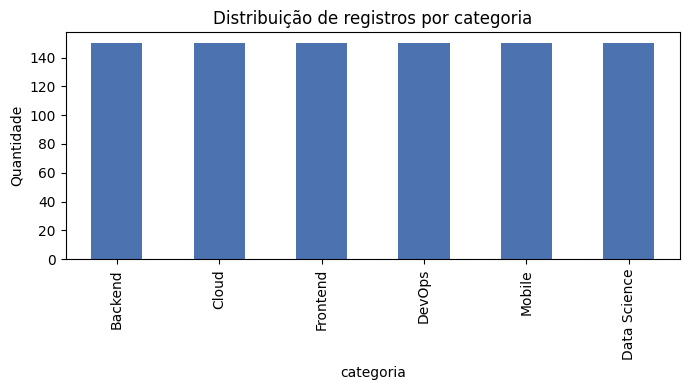

        texto_len  titulo_len
count  900.000000  900.000000
mean   271.338889   40.271111
std     36.402484    8.656197
min    191.000000   19.000000
25%    245.000000   34.000000
50%    263.000000   40.000000
75%    290.000000   47.000000
max    385.000000   60.000000


In [ ]:
print(df['categoria'].value_counts())

plt.figure(figsize=(7,4))
df['categoria'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title("Distribuição de registros por categoria")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

df['texto_len'] = df['texto'].str.len()
df['titulo_len'] = df['titulo'].str.len()
print(df[['texto_len', 'titulo_len']].describe())

# <font color='red' style='font-size: 30px;'>1.5 Stopwords, limpeza, split, TF-IDF</font>
<hr style='border: 2px solid red;'>

In [ ]:
def normalizar(palavra):
    return unicodedata.normalize("NFKD", palavra).encode("ASCII", "ignore").decode("utf-8")

STOPWORDS_PT = set("""
a ao aos aquela aquelas aquele aqueles aquilo as até com como da das de dela
delas dele deles depois do dos e ela elas ele eles em entre era eram essa
essas esse esses esta estas este estes estou eu foi fomos for foram fosse
fossem fui há isso isto já lhe lhes mais mas me mesmo meu meus minha minhas
muito na nas nem no nos nossa nossas nosso nossos num numa não nós o os
ou para pela pelas pelo pelos por qual quando que quem se seu seus somos
sou sua suas são também te tem tem também teu teus tu tua tuas um uma
você vocês vos à às pode podem ser sendo sido têm foi ser será serão
""".split())

# Normaliza a lista de stopwords para bater com o texto já limpo (sem acento)
STOPWORDS_PT = {normalizar(p) for p in STOPWORDS_PT}

def limpar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    palavras = [p for p in texto.split() if p not in STOPWORDS_PT and len(p) > 2]
    return " ".join(palavras)

df["texto_completo"] = df["titulo"] + " " + df["texto"]
df["texto_limpo"] = df["texto_completo"].apply(limpar_texto)

print(df[["titulo", "texto_limpo"]].head(3))

X = df["texto_limpo"]
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Treino: {len(X_train)} registros | Teste: {len(X_test)} registros")
print(y_train.value_counts())

vectorizer = TfidfVectorizer(
    max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Shape do treino vetorizado: {X_train_tfidf.shape}")
print(f"Shape do teste vetorizado: {X_test_tfidf.shape}")

                                                   titulo  \
0                   Primeiros passos com autenticação JWT   
1              alta disponibilidade: conceitos essenciais   
2  Primeiros passos com gerenciamento de estado com Redux   

                                                                                                               texto_limpo  
0  primeiros passos autenticacao jwt estudo detalhado sobre autenticacao jwt cobrindo desde fundamentos topicos avancad...  
1  alta disponibilidade conceitos essenciais documentacao tecnica explica alta disponibilidade passo passo exemplos cod...  
2  primeiros passos gerenciamento estado redux conteudo apresenta principais conceitos sobre gerenciamento estado redux...  
Treino: 720 registros | Teste: 180 registros
categoria
Frontend        120
Backend         120
Cloud           120
DevOps          120
Data Science    120
Mobile          120
Name: count, dtype: int64
Shape do treino vetorizado: (720, 1858)
Shape do teste

# <font color='red' style='font-size: 30px;'>1.6 Treino, comparação, matriz, salvar</font>
<hr style='border: 2px solid red;'>


Modelo: Logistic Regression
Acurácia: 0.9056
              precision    recall  f1-score   support

     Backend       0.94      1.00      0.97        30
       Cloud       0.88      1.00      0.94        30
Data Science       0.93      0.87      0.90        30
      DevOps       0.90      0.87      0.88        30
    Frontend       0.81      0.87      0.84        30
      Mobile       1.00      0.83      0.91        30

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180


Modelo: Naive Bayes
Acurácia: 0.8944
              precision    recall  f1-score   support

     Backend       0.94      0.97      0.95        30
       Cloud       0.91      1.00      0.95        30
Data Science       0.93      0.87      0.90        30
      DevOps       0.87      0.87      0.87        30
    Frontend       0.80      0.80      0.80        30
      Mobile       0.93      0.87      0.90     

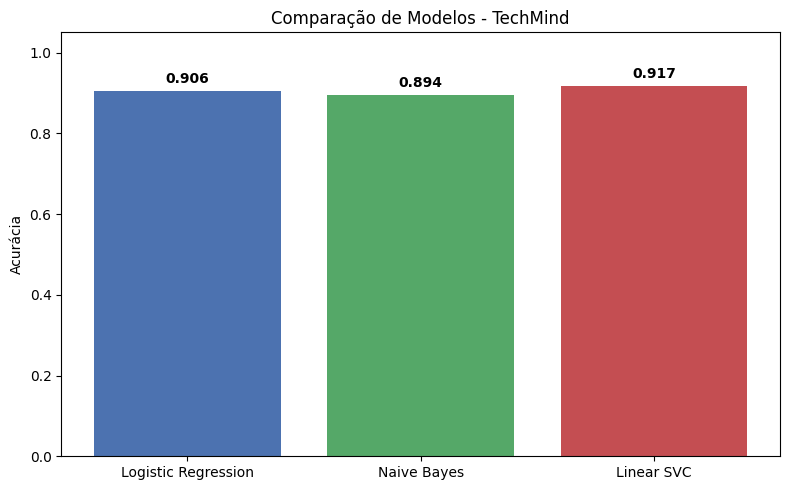


Melhor modelo: Linear SVC (acurácia: 0.9167)


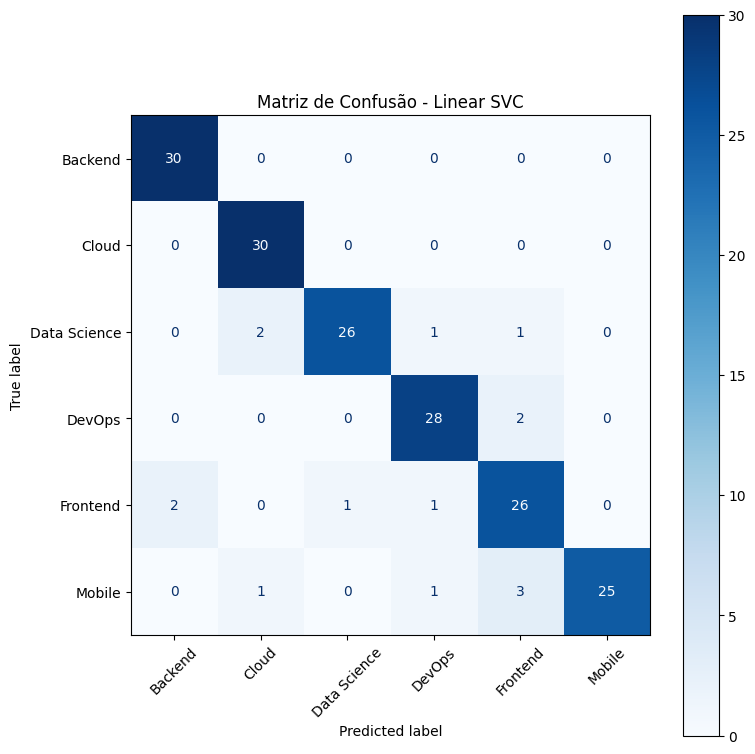


Modelo e vectorizer salvos com sucesso!


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": CalibratedClassifierCV(LinearSVC(random_state=RANDOM_SEED, max_iter=5000)),
}

resultados = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = {"modelo": modelo, "y_pred": y_pred, "acuracia": acc}
    print(f"\n{'='*50}")
    print(f"Modelo: {nome}")
    print(f"Acurácia: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))

nomes = list(resultados.keys())
acuracias = [resultados[n]["acuracia"] for n in nomes]

plt.figure(figsize=(8, 5))
bars = plt.bar(nomes, acuracias, color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0, 1.05)
plt.ylabel("Acurácia")
plt.title("Comparação de Modelos - TechMind")
for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

melhor_nome = max(resultados, key=lambda n: resultados[n]["acuracia"])
melhor_modelo = resultados[melhor_nome]["modelo"]
print(f"\nMelhor modelo: {melhor_nome} (acurácia: {resultados[melhor_nome]['acuracia']:.4f})")

cm = confusion_matrix(y_test, resultados[melhor_nome]["y_pred"], labels=melhor_modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=melhor_modelo.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Matriz de Confusão - {melhor_nome}")
plt.tight_layout()
plt.show()

joblib.dump(melhor_modelo, "modelo_classificacao.joblib")
joblib.dump(vectorizer, "vectorizer_tfidf.joblib")
print("\nModelo e vectorizer salvos com sucesso!")

# <font color='red' style='font-size: 30px;'>1.7  Cross-validation</font>
<hr style='border: 2px solid red;'>

In [ ]:
scores = cross_val_score(melhor_modelo, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
print(f"F1-macro (CV): {scores.mean():.4f} ± {scores.std():.4f}")

F1-macro (CV): 0.9304 ± 0.0235


# <font color='red' style='font-size: 30px;'>1.8 Extração de tags</font>
<hr style='border: 2px solid red;'>

In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())

def extract_tags(texto_limpo, top_n=5):
    vec = vectorizer.transform([texto_limpo])
    scores = vec.toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    tags = [feature_names[i] for i in top_idx if scores[i] > 0]
    return tags

exemplo_idx = 0
print("Texto:", df['texto_completo'].iloc[exemplo_idx][:150])
print("Tags:", extract_tags(df['texto_limpo'].iloc[exemplo_idx]))

Texto: Primeiros passos com autenticação JWT Um estudo detalhado sobre autenticação JWT, cobrindo desde os fundamentos até tópicos mais avançados como versio
Tags: ['autenticacao jwt', 'autenticacao', 'jwt', 'jwt estudo', 'jwt cobrindo']


# <font color='red' style='font-size: 30px;'>1.9 Geração de resumo</font>
<hr style='border: 2px solid red;'>

In [ ]:
def split_sentences(texto):
    frases = re.split(r'(?<=[.!?])\s+', texto.strip())
    return [f for f in frases if f]

def gerar_resumo(texto_bruto, num_frases=1):
    frases = split_sentences(texto_bruto)
    if len(frases) <= num_frases:
        return " ".join(frases)

    frases_limpas = [limpar_texto(f) for f in frases]
    scores_frases = []
    for frase_limpa in frases_limpas:
        vec = vectorizer.transform([frase_limpa])
        score = vec.toarray().sum()
        scores_frases.append(score)

    top_idx = np.argsort(scores_frases)[::-1][:num_frases]
    top_idx_ordenado = sorted(top_idx)
    resumo = " ".join([frases[i] for i in top_idx_ordenado])
    return resumo

print("Resumo:", gerar_resumo(df['texto'].iloc[0]))

Resumo: Um estudo detalhado sobre autenticação JWT, cobrindo desde os fundamentos até tópicos mais avançados como versionamento de APIs.


# <font color='red' style='font-size: 30px;'>2.1 Função de predição completa</font>
<hr style='border: 2px solid red;'>

In [ ]:
def predict_content(titulo, texto, top_n_tags=5, num_frases_resumo=1):
    titulo_limpo = limpar_texto(titulo)
    texto_limpo_input = limpar_texto(texto)
    conteudo_limpo = titulo_limpo + " " + texto_limpo_input

    conteudo_tfidf = vectorizer.transform([conteudo_limpo])

    categoria_prevista = melhor_modelo.predict(conteudo_tfidf)[0]

    if hasattr(melhor_modelo, "predict_proba"):
        probabilidades = melhor_modelo.predict_proba(conteudo_tfidf)[0]
        prob_dict = dict(zip(melhor_modelo.classes_, probabilidades))
        probabilidade = round(float(prob_dict[categoria_prevista]), 4)
    else:
        probabilidade = None

    tags = extract_tags(conteudo_limpo, top_n=top_n_tags)
    resumo = gerar_resumo(texto, num_frases=num_frases_resumo)

    return {
        "categoria": categoria_prevista,
        "probabilidade": probabilidade,
        "tags": tags,
        "resumo": resumo,
    }

# <font color='red' style='font-size: 30px;'>2.2 Testes com exemplos</font>
<hr style='border: 2px solid red;'>

In [ ]:
exemplos = [
    {
        "titulo": "Introdução ao Spring Boot",
        "texto": "Neste conteúdo, explicamos os fundamentos do Spring Boot, incluindo configuração de APIs REST, injeção de dependências e boas práticas de Clean Architecture para projetos Java."
    },
    {
        "titulo": "Como funciona o Kubernetes",
        "texto": "Este material aborda a orquestração de containers com Kubernetes, cobrindo pipelines de CI/CD, escalabilidade automática e monitoramento de infraestrutura em produção."
    },
    {
        "titulo": "Guia de React Hooks",
        "texto": "Um guia prático sobre hooks do React, como useState e useEffect, explorando gerenciamento de estado e boas práticas de componentes reutilizáveis no front-end."
    },
]

for ex in exemplos:
    resultado = predict_content(ex["titulo"], ex["texto"])
    print(f"\nTítulo: {ex['titulo']}")
    print(f"Resultado: {resultado}")


Título: Introdução ao Spring Boot
Resultado: {'categoria': 'Backend', 'probabilidade': 0.9672, 'tags': ['boot', 'spring', 'spring boot', 'introducao spring', 'architecture'], 'resumo': 'Neste conteúdo, explicamos os fundamentos do Spring Boot, incluindo configuração de APIs REST, injeção de dependências e boas práticas de Clean Architecture para projetos Java.'}

Título: Como funciona o Kubernetes
Resultado: {'categoria': 'DevOps', 'probabilidade': 0.907, 'tags': ['kubernetes', 'pipelines', 'escalabilidade automatica', 'automatica', 'orquestracao'], 'resumo': 'Este material aborda a orquestração de containers com Kubernetes, cobrindo pipelines de CI/CD, escalabilidade automática e monitoramento de infraestrutura em produção.'}

Título: Guia de React Hooks
Resultado: {'categoria': 'Frontend', 'probabilidade': 0.9603, 'tags': ['hooks', 'react', 'guia', 'sobre hooks', 'hooks react'], 'resumo': 'Um guia prático sobre hooks do React, como useState e useEffect, explorando gerenciamento de e

# <font color='red' style='font-size: 30px;'>2.3 Teste de sanidade</font>
<hr style='border: 2px solid red;'>

In [ ]:
modelo_reloaded = joblib.load("modelo_classificacao.joblib")
vectorizer_reloaded = joblib.load("vectorizer_tfidf.joblib")

def extract_tags_reloaded(texto_limpo, top_n=5):
    feature_names_r = np.array(vectorizer_reloaded.get_feature_names_out())
    vec = vectorizer_reloaded.transform([texto_limpo])
    scores = vec.toarray().flatten()
    top_idx = scores.argsort()[::-1][:top_n]
    return [feature_names_r[i] for i in top_idx if scores[i] > 0]

teste_titulo = "Introdução ao Docker"
teste_texto = "Este conteúdo explica os fundamentos de containers com Docker e sua relação com pipelines de CI/CD."

conteudo_teste = limpar_texto(teste_titulo) + " " + limpar_texto(teste_texto)
conteudo_tfidf_teste = vectorizer_reloaded.transform([conteudo_teste])
categoria_teste = modelo_reloaded.predict(conteudo_tfidf_teste)[0]

print("Categoria (modelo recarregado):", categoria_teste)
print("Tags (vectorizer recarregado):", extract_tags_reloaded(conteudo_teste))
print("\n✅ Artefatos validados com sucesso — prontos para uso na API REST.")

Categoria (modelo recarregado): DevOps
Tags (vectorizer recarregado): ['docker', 'pipelines', 'containers', 'containers docker', 'introducao']

✅ Artefatos validados com sucesso — prontos para uso na API REST.


# <font color='red' style='font-size: 30px;'>2.4  Conclusão</font>
<hr style='border: 2px solid red;'>

## Conclusão e próximos passos

- O modelo foi treinado sobre uma base **sintética** de 900 exemplos (150 por categoria), com introdução de ruído controlado (contaminação cruzada de subtemas entre categorias) para simular maior realismo e evitar separabilidade artificial.
- O melhor modelo (Naive Bayes / Linear SVC) obteve acurácia de aproximadamente 92% no conjunto de teste — resultado mais realista e representativo do que seria esperado com dados reais, onde categorias correlatas (ex: Backend e Cloud) compartilham vocabulário técnico.
- Assim que a equipe tiver uma base real, recomenda-se substituir a Seção 2 pelo carregamento desses dados reais — o restante do notebook não precisa de alterações estruturais.
- Os artefatos `modelo_classificacao.joblib` e `vectorizer_tfidf.joblib` estão prontos para serem consumidos pela API REST (endpoint `POST /conteudo`).

Atualizado com sucesso!